Report 5


Anh Do

020416-2317

anhd@kth.se

In [108]:
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import numpy as np
from gurobipy import GRB
import gurobipy as gp
from pyomo.opt import SolverFactory

WLS = { # Please dont steal my credentials
    "WLSACCESSID": "1e6bdedb-f27d-4b0c-8a0d-24a8c94a8cb5",
    "WLSSECRET": "47ebeda5-b872-4365-9981-ef8044c28db5",
    "LICENSEID": 2707350,
}

# Problem 1

## Code

### ECP

In [109]:
def build_ecp_model():
    m = pyo.ConcreteModel()
    m.I = pyo.RangeSet(1, 8)

    def bounds_rule(m, i):
        if i >= 5: 
            return (0, 3)
        return (-2, 2)
    
    def domain_rule(m, i):
        if i >= 5:
            return pyo.Integers
        return pyo.Reals

    m.x = pyo.Var(m.I, bounds=bounds_rule, domain=domain_rule)
    m.obj = pyo.Objective(expr=-sum(m.x[i] for i in m.I), sense=pyo.minimize)
    
    # Linear constraint
    m.linear_const = pyo.Constraint(expr=m.x[1] + m.x[3] + m.x[5] + m.x[7] <= 2)
    
    # Container for ECP cuts
    m.ecp_cuts = pyo.ConstraintList()

    return m

In [110]:
grb_params = {"TimeLimit": 300, "MIPFocus": 1, "OutputFlag": 0}

with pyo.SolverFactory('gurobi_persistent', manage_env=True) as solver:
    solver.set_options(WLS)
    solver.options.update(grb_params)
    
    model = build_ecp_model()
    solver.set_instance(model)
    
    tol = 1e-4
    max_iter = 1000
    iteration = 0

    print(f"{'Iter':<5} | {'Obj Value':<12} | {'Violation':<12}")
    print("-" * 40)

    while iteration < max_iter:
        iteration += 1
        
        # 1. Solve Master
        solver.solve(model)
        
        # 2. Get current values
        x_val = {i: pyo.value(model.x[i]) for i in model.I}
        current_obj = pyo.value(model.obj)
        
        # 3. Check Constraint Violation: sum(x^2) - 3 <= 0
        sum_sq = sum(x_val[i]**2 for i in model.I)
        g_val = sum_sq - 3
        
        if g_val <= tol:
            print(f"{iteration:<5} | {current_obj:<12.6f} | {g_val:<12.6f} (Converged!)")
            break
        
        print(f"{iteration:<5} | {current_obj:<12.6f} | {g_val:<12.6f}")
        
        # 4. Add Cut: g(x^k) + grad * (x - x^k) <= 0
        # g(x^k) = g_val
        # grad = 2 * x_val
        lhs = g_val + sum(2 * x_val[i] * (model.x[i] - x_val[i]) for i in model.I)
        
        model.ecp_cuts.add(lhs <= 0)
        solver.add_constraint(model.ecp_cuts[len(model.ecp_cuts)])

    print("-" * 40)
    print("Final Solution:")
    for i in model.I:
        print(f"x[{i}] = {pyo.value(model.x[i]):.6f}")

Iter  | Obj Value    | Violation   
----------------------------------------
1     | -12.000000   | 27.000000   
2     | -10.000000   | 27.000000   
3     | -9.583333    | 24.395833   
4     | -8.750000    | 19.062500   
5     | -8.750000    | 11.062500   
6     | -7.760417    | 12.557617   
7     | -7.414279    | 17.607152   
8     | -7.340979    | 7.384568    
9     | -6.871026    | 17.870325   
10    | -6.743382    | 7.335322    
11    | -6.665778    | 5.574822    
12    | -6.448804    | 6.055243    
13    | -6.427411    | 4.819187    
14    | -6.244850    | 3.341987    
15    | -6.035800    | 7.548069    
16    | -5.927437    | 3.082011    
17    | -5.579046    | 3.343273    
18    | -5.573984    | 4.257775    
19    | -5.536929    | 2.241301    
20    | -5.453806    | 3.354415    
21    | -5.390747    | 3.257580    
22    | -5.356249    | 1.833128    
23    | -5.288019    | 2.181599    
24    | -5.223485    | 5.386811    
25    | -5.197924    | 1.738826    
26    | -5.174643    | 

### OA (Outer Approximation)

We solve the MINLP with a convex quadratic constraint using a clean OA loop:

1. Solve the NLP with fixed integer variables $y=(x_5,x_6,x_7,x_8)$.
2. Add a supporting cut from the convex constraint $g(x)=\sum_i x_i^2-3 \le 0$.
3. Solve the master MILP (linear objective + linear constraints + cuts).
4. Repeat until the gap closes or the master becomes infeasible.

The code below is a full rewrite to improve robustness and convergence.

In [111]:
# --- OA: core helpers (minimal) ---

def create_gurobi_env():
    env = gp.Env(empty=True)
    for key, value in WLS.items():
        env.setParam(key, value)
    env.setParam("OutputFlag", 0)
    env.start()
    return env


def build_bounds():
    return {i: (0, 3) if i >= 5 else (-2, 2) for i in range(1, 9)}


def g_value(x_point):
    return sum(x_point[i] ** 2 for i in range(1, 9)) - 3


def build_master(env, bounds):
    m = gp.Model(env=env)
    m.Params.OutputFlag = 0

    x = {}
    for i in range(1, 9):
        lb, ub = bounds[i]
        vtype = GRB.INTEGER if i >= 5 else GRB.CONTINUOUS
        x[i] = m.addVar(lb=lb, ub=ub, vtype=vtype, name=f"x[{i}]")

    m.addConstr(x[1] + x[3] + x[5] + x[7] <= 2, name="static_cut")
    m.setObjective(-gp.quicksum(x[i] for i in range(1, 9)), GRB.MINIMIZE)
    m.update()
    return m, x


def build_nlp(env, bounds, y_fixed, relax=False):
    m = gp.Model(env=env)
    m.Params.OutputFlag = 0

    x = {}
    for i in range(1, 9):
        lb, ub = bounds[i]
        if i >= 5:
            lb = ub = y_fixed[i]
        x[i] = m.addVar(lb=lb, ub=ub, vtype=GRB.CONTINUOUS, name=f"x[{i}]")

    m.addConstr(x[1] + x[3] + x[5] + x[7] <= 2, name="lincon")

    if relax:
        u = m.addVar(lb=0.0, vtype=GRB.CONTINUOUS, name="u")
        m.addQConstr(gp.quicksum(x[i] * x[i] for i in range(1, 9)) - 3 <= u, name="quadcon_relaxed")
        m.setObjective(u, GRB.MINIMIZE)
        m.update()
        return m, x, u

    m.addQConstr(gp.quicksum(x[i] * x[i] for i in range(1, 9)) <= 3, name="quadcon")
    m.setObjective(-gp.quicksum(x[i] for i in range(1, 9)), GRB.MINIMIZE)
    m.update()
    return m, x


def apply_params(m, params):
    if params:
        for k, v in params.items():
            m.setParam(k, v)

In [ ]:
# --- OA: solve loop (merged init + main loop) ---

grb_params = {"TimeLimit": 300, "MIPFocus": 1, "OutputFlag": 0}
max_iter = 200
tol = 1e-4
gap_tol = 1e-4

# Initial integer point y0 = (x5,x6,x7,x8)
y0 = {5: 0, 6: 0, 7: 0, 8: 0}

bounds = build_bounds()
for i in range(5, 9):
    lb, ub = bounds[i]
    if int(y0[i]) != y0[i] or not (lb <= y0[i] <= ub):
        raise ValueError(f"y0[{i}]={y0[i]} must be an integer in [{lb},{ub}]")

env = create_gurobi_env()
master_model, x_master = build_master(env, bounds)
apply_params(master_model, grb_params)

best = {"obj": float("inf"), "x": None, "y": None}
hist = []

print(f"{'Iter':<6} | {'LB(master)':<12} | {'UB(best)':<12} | {'g(master)':<12} | {'y(5-8)':<24} | Note")
print("-" * 105)

for k in range(0, max_iter + 1):
    if k == 0:
        y_m = y0.copy()
        lb = None
        g_m = None
    else:
        master_model.optimize()
        if master_model.Status in (GRB.INFEASIBLE, GRB.INF_OR_UNBD):
            hist.append({"iter": k, "lb": None, "ub": best["obj"], "g": None, "y": None, "note": "Master infeasible"})
            break
        if master_model.SolCount == 0:
            raise RuntimeError(f"Master terminated with status {master_model.Status} and no solution.")

        x_m = {i: x_master[i].X for i in range(1, 9)}
        y_m = {i: int(round(x_m[i])) for i in range(5, 9)}
        lb = master_model.ObjVal
        g_m = g_value(x_m)

    # Solve NLP at current integer y
    nlp_model, nlp_x = build_nlp(env, bounds, y_m, relax=False)
    apply_params(nlp_model, grb_params)
    nlp_model.optimize()

    note = ""
    if nlp_model.Status == GRB.OPTIMAL:
        x_k = {i: nlp_x[i].X for i in range(1, 9)}
        if nlp_model.ObjVal < best["obj"]:
            best["obj"] = nlp_model.ObjVal
            best["x"] = x_k
            best["y"] = y_m.copy()
        g_pt = g_value(x_k)
        expr = g_pt + gp.quicksum(2 * x_k[i] * (x_master[i] - x_k[i]) for i in range(1, 9))
        master_model.addConstr(expr <= 0, name=f"oa_cut_{k}")
        master_model.update()
        note = "NLP feasible"
    else:
        feas_model, feas_x, feas_u = build_nlp(env, bounds, y_m, relax=True)
        apply_params(feas_model, grb_params)
        feas_model.optimize()
        x_kf = {i: feas_x[i].X for i in range(1, 9)}
        g_pt = g_value(x_kf)
        expr = g_pt + gp.quicksum(2 * x_kf[i] * (x_master[i] - x_kf[i]) for i in range(1, 9))
        master_model.addConstr(expr <= 0, name=f"oa_infeas_cut_{k}")
        master_model.update()
        note = f"NLP infeas (u={feas_u.X:.2e})"

    if k > 0 and g_m is not None and g_m > tol:
        g_pt = g_value(x_m)
        expr = g_pt + gp.quicksum(2 * x_m[i] * (x_master[i] - x_m[i]) for i in range(1, 9))
        master_model.addConstr(expr <= 0, name=f"ecp_cut_{k}")
        master_model.update()
        note += "; master violated g(x)"

    ub = best["obj"] if best["obj"] < float("inf") else np.nan
    hist.append({"iter": k, "lb": lb, "ub": ub, "g": g_m, "y": y_m.copy(), "note": note})

    if lb is not None and best["obj"] < float("inf") and (best["obj"] - lb) <= gap_tol:
        hist.append({"iter": k + 0.1, "lb": lb, "ub": best["obj"], "g": g_m, "y": y_m.copy(), "note": f"DONE (gap={best['obj'] - lb:.2e})"})
        break

# Report
print("-" * 105)
print("Final Solution:")
if best["x"] is None:
    print("No feasible solution found.")
else:
    print(f"Objective: {best['obj']:.6f}")
    print(f"y(5-8) = {best['y']}")
    for i in range(1, 9):
        print(f"x[{i}] = {best['x'][i]}")

# Pretty log output
for r in hist:
    lb = " " * 12 if r["lb"] is None else f"{float(r['lb']):12.6f}"
    ub = " " * 12 if r["ub"] is None else f"{float(r['ub']):12.6f}"
    g = " " * 12 if r["g"] is None else f"{float(r['g']):12.6f}"
    print(f"{r['iter']:<6} | {lb} | {ub} | {g} | {str(r['y']):<24} | {r['note']}")

Iter   | LB(master)   | UB(best)     | g(master)    | y(5-8)                   | Note
---------------------------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------------------------
Final Solution:
Objective: -4.000000
y(5-8) = {5: 0, 6: 1, 7: 0, 8: 1}
x[1] = 0.4998503204232343
x[2] = 0.5001495715170945
x[3] = 0.4998503204232343
x[4] = 0.5001495715170945
x[5] = 0.0
x[6] = 1.0
x[7] = 0.0
x[8] = 1.0
0      |              |    -3.464101 |              | {5: 0, 6: 0, 7: 0, 8: 0} | NLP feasible
1      |   -12.000000 |    -3.464101 |    49.000000 | {5: 3, 6: 3, 7: 3, 8: 3} | NLP infeas (u=4.10e+01); master violated g(x)
2      |   -10.464336 |    -3.464101 |    27.230373 | {5: 1, 6: 3, 7: 0, 8: 3} | NLP infeas (u=1.60e+01); master violated g(x)
3      |    -8.750000 |    -3.464101 |    27.062500 | {5: 0, 6: 3, 7: 3, 8: 0} | NLP infeas (u=1.55e+01); master violated g(x)
4      |

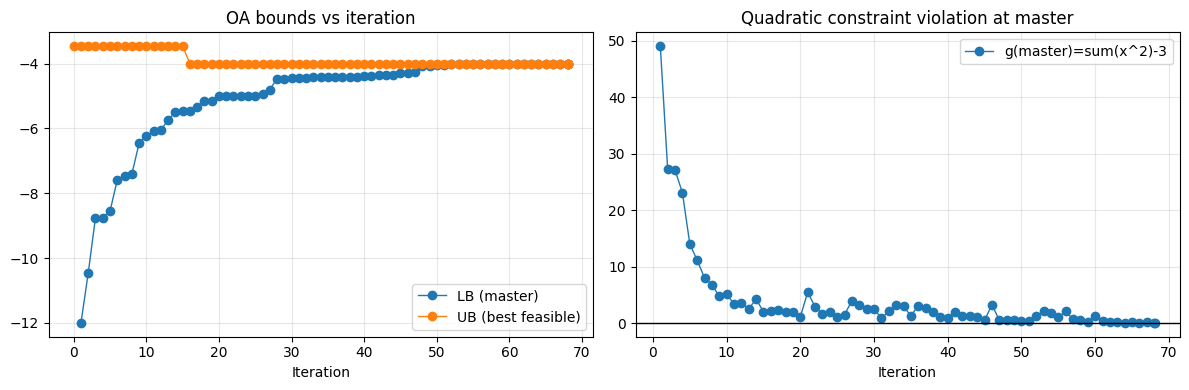

In [113]:
# --- OA: plots ---
if len(hist) == 0:
    print("No history to plot.")
else:
    iters = np.array([r["iter"] for r in hist], dtype=float)
    lb_arr = np.array([r["lb"] for r in hist], dtype=float)
    ub_arr = np.array([r["ub"] for r in hist], dtype=float)
    g_arr = np.array([r["g"] for r in hist], dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(iters, lb_arr, marker='o', linewidth=1, label='LB (master)')
    axes[0].plot(iters, ub_arr, marker='o', linewidth=1, label='UB (best feasible)')
    axes[0].set_title('OA bounds vs iteration')
    axes[0].set_xlabel('Iteration')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(iters, g_arr, marker='o', linewidth=1, label='g(master)=sum(x^2)-3')
    axes[1].axhline(0.0, color='k', linewidth=1)
    axes[1].set_title('Quadratic constraint violation at master')
    axes[1].set_xlabel('Iteration')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()